In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
%matplotlib inline
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pseudovelo as pv

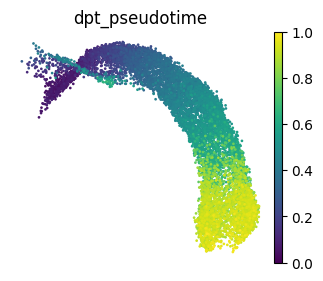

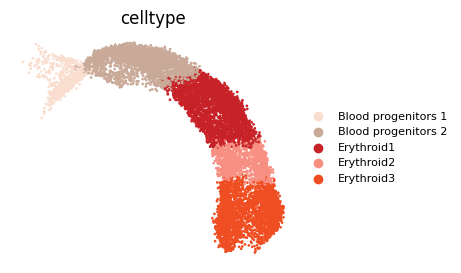

In [ ]:
#cal dpt_pseudotime
adata_dpt=sc.read_h5ad("../data/gas/MouseErythroid_anndata.h5ad")
sc.pp.filter_genes(adata_dpt, min_cells=10)
sc.pp.normalize_total(adata_dpt)
sc.pp.log1p(adata_dpt)
sc.pp.highly_variable_genes(adata_dpt, n_top_genes=2000)
adata_dpt = adata_dpt[:, adata_dpt.var.highly_variable].copy()
sc.tl.pca(adata_dpt)
sc.pp.neighbors(adata_dpt, n_neighbors=30, n_pcs=30)

start_cell_index = np.where(adata_dpt.obs["celltype"] == "Blood progenitors 1")[0][0]
root_cell = adata_dpt.obs_names[start_cell_index]
adata_dpt.uns["iroot"] = start_cell_index
sc.tl.diffmap(adata_dpt)
sc.tl.dpt(adata_dpt)

fig, ax = plt.subplots(figsize=(3.7,3))
sc.pl.embedding(adata_dpt, basis="umap", color=["dpt_pseudotime"],frameon=False,ax=ax,size=15,title="dpt_pseudotime",legend_fontsize=8)

fig, ax = plt.subplots(figsize=(3.7,3))
sc.pl.embedding(adata_dpt, basis="umap", color=["celltype"],frameon=False,ax=ax,size=15,title="celltype",legend_fontsize=8)

[global] J range = 1, eps = 1e-06 (eps_factor = 1e-06)
Fitting NB GLMGam on all cells (no clustering).
Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 10 (factor = 1), n_jobs = 10.
Stored μ in adata.layers['gam_X'] with shape (9815, 2000)
Stored dμ/dJ in adata.layers['gam_X_J'] with shape (9815, 2000)


  0%|          | 0/9815 [00:00<?, ?cells/s]

computing velocity graph
finished.


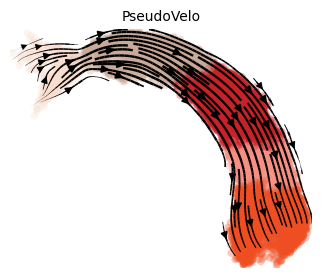

computing velocity embedding
finished.


In [4]:
#PseudoVelo
adata_dpt.layers["X"]=adata_dpt.X.toarray()
pv.fit_nb_gam_with_center_diff(adata_dpt,J_key="dpt_pseudotime",n_jobs=10,cluster_key=None,input_layer="X",reverse=False,output_layer="gam_X",dmu_layer="gam_X_J")
pv.plot_velocity_projection(adata_dpt,xkey="X",vkey="gam_X_J",basis="umap",color="celltype",figsize=(3.9,3.1),title="PseudoVelo",size=120,legend_loc="none")


  0%|          | 0/9815 [00:00<?, ?cell/s]

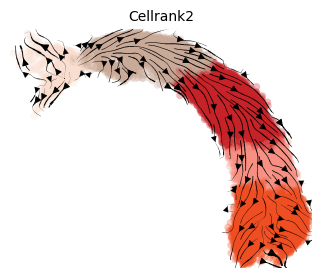

In [5]:
#cellrank2
import cellrank as cr
pk = cr.kernels.PseudotimeKernel(adata_dpt, time_key="dpt_pseudotime")
pk.compute_transition_matrix()
pk.write_to_adata()
pk.plot_projection(basis="umap", color="celltype",show=False,figsize=(3.9,3.1),title="Cellrank2",s=120,legend_fontsize=8,legend_loc="none")
ax = plt.gca()
ax.grid(False)
plt.show()

AnnData object with n_obs × n_vars = 9815 × 53801
    obs: 'sample', 'stage', 'sequencing.batch', 'theiler', 'celltype', 'clusters'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'MURK_gene', 'Δm', 'scaled Δm'
    uns: 'celltype_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
This detected 2000 highly variable genes. 
INFO     Initialized CellMapper for self-mapping with 9815 cells.                                                  
INFO     Self-mapping mode detected. Computing only yx neighbors for efficiency (all neighbor matrices will contain
         the same information).                                                                                    
INFO     Using sklearn to compute 30 neighbors.                                                                    
INFO     Computing mapping matrix using kernel method 'umap'.                                                      
INFO     Mapping layer for key 'X' using direct multiplication

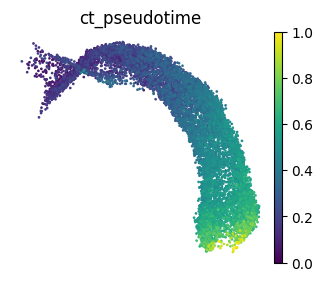

[global] J range = 1, eps = 1e-06 (eps_factor = 1e-06)
Fitting NB GLMGam on all cells (no clustering).
Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 10 (factor = 1), n_jobs = 10.


c:\Users\shuxin\anaconda3\envs\celldyc_test5\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


KeyboardInterrupt: 

In [6]:
from cellmapper import CellMapper

adata=sc.read_h5ad("../../veloPotential/data/gas/MouseErythroid_anndata.h5ad")
print(adata)
adata_ct = adata.copy()

#cal ct_pseudotime
sc.pp.filter_genes(adata_ct, min_cells=10)
sc.pp.normalize_total(adata_ct)
sc.pp.log1p(adata_ct)
sc.pp.highly_variable_genes(adata_ct,n_top_genes=2000)
print(f"This detected {adata_ct.var['highly_variable'].sum()} highly variable genes. ")
sc.tl.pca(adata_ct)
sc.pp.neighbors(adata_ct, n_neighbors=30, n_pcs=30)
adata_ct.layers["imputed"] = (
    CellMapper(adata_ct).map(layer_key="X", use_rep="X_pca").query_imputed.X.copy()
)
from cellrank.kernels import CytoTRACEKernel
ctk = CytoTRACEKernel(adata_ct).compute_cytotrace(layer="imputed")
fig, ax = plt.subplots(figsize=(3.7,3))
sc.pl.embedding(adata_ct, basis="umap", color="ct_pseudotime",frameon=False,ax=ax,size=15,title="ct_pseudotime",legend_fontsize=8)

#PseudoVelo
adata_ct_=adata_ct.copy()
adata_ct=adata.copy()
sc.pp.filter_genes(adata_ct, min_cells=10)
sc.pp.normalize_total(adata_ct)
sc.pp.log1p(adata_ct)
sc.pp.highly_variable_genes(adata_ct,n_top_genes=2000)
adata_ct = adata_ct[:, adata_ct.var['highly_variable']].copy()
sc.tl.pca(adata_ct)
sc.pp.neighbors(adata_ct, n_neighbors=30, n_pcs=30)
adata_ct.layers["X"]=adata_ct.X.toarray()
adata_ct.obs["ct_pseudotime"]=adata_ct_.obs["ct_pseudotime"]
pv.fit_nb_gam_with_center_diff(adata_ct,J_key="ct_pseudotime",n_jobs=10,cluster_key=None,input_layer="X",reverse=False,output_layer="gam_X",dmu_layer="gam_X_J")
pv.plot_velocity_projection(adata_ct,xkey="X",vkey="gam_X_J",basis="umap",color="celltype",figsize=(3.9,3.1),title="PseudoVelo",size=120,legend_loc="none")

#cellrank2
ctk.compute_transition_matrix()
ctk.plot_projection(basis="umap",color="celltype",figsize=(3.9,3.1),title="Cellrank2",s=120,legend_fontsize=8,legend_loc="none")

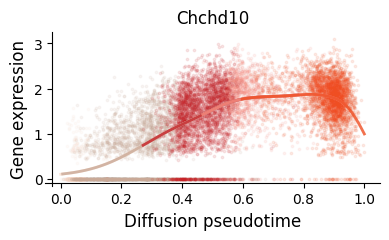

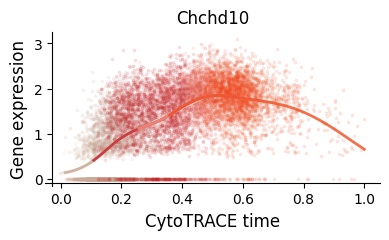

In [ ]:
pv.plot_gam_fit(adata_dpt,J_key="dpt_pseudotime",mu_layer="gam_X",input_layer="X",cluster_key="celltype",gene_list=["Chchd10"],figsize=(4,2.5),fontsize=12,xlabel="Diffusion pseudotime")
pv.plot_gam_fit(adata_ct,J_key="ct_pseudotime",mu_layer="gam_X",input_layer="X",cluster_key="celltype",gene_list=["Chchd10"],figsize=(4,2.5),fontsize=12,xlabel="CytoTRACE time")

In [ ]:
gene2 = "Chchd10"
v1_g2 = adata_dpt.layers["gam_X_J"][:, adata_dpt.var_names.get_loc(gene2)]
v2_g2 = adata_ct.layers["gam_X_J"][:, adata_ct.var_names.get_loc(gene2)]
sign_v1_g2 = np.sign(v1_g2)
sign_v2_g2 = np.sign(v2_g2)
g2 = (sign_v1_g2 == sign_v2_g2).sum() / len(sign_v1_g2)
print(g2)

0.9028018339276618


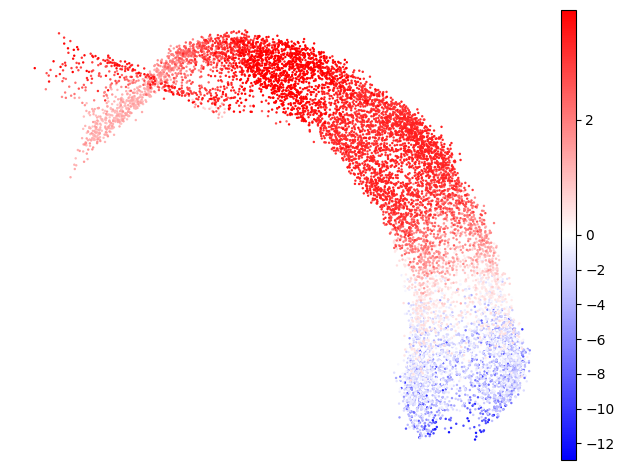

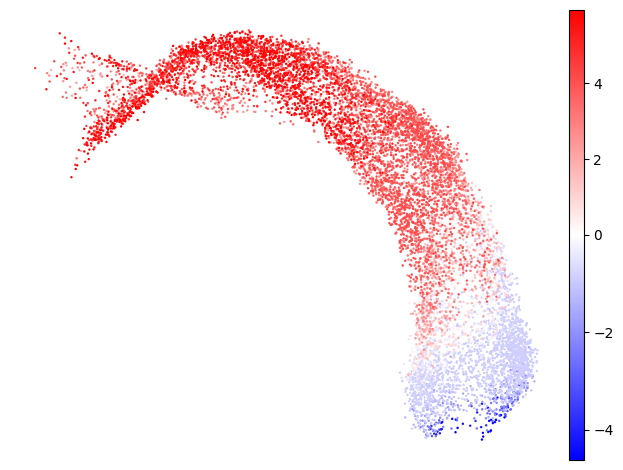

In [ ]:
obs_col_name = f"{gene2}_dmu_dJ"
adata_dpt.obs[obs_col_name] = v1_g2
adata_ct.obs[obs_col_name] = v2_g2

sc.pl.embedding(
    adata_dpt, 
    basis="umap",  
    color=obs_col_name,              
    show=False,              
    title="",             
    frameon=False,        
    cmap="bwr",       
    vcenter=0,legend_fontsize=18    
)
plt.tight_layout()
plt.show()         

sc.pl.embedding(
    adata_ct, 
    basis="umap", 
    color=obs_col_name,
    show=False,
    title="",             
    frameon=False,        
    cmap="bwr",       
    vcenter=0,legend_fontsize=18   
)
plt.tight_layout()
plt.show()